# Stage 3: LSTM-based ECM Parameter Prediction

Extract relaxation segments from discharge cycles and build an LSTM to predict V_RC1 that varies with cell aging.

**Flow:**
1. Extract relaxation segments from discharge cycles
2. Fit exponential RC decay to estimate V_RC1_init
3. Build sliding-window LSTM training dataset
4. Train 2-layer LSTM with dropout
5. Evaluate on cross-battery validation (B0005 → B0006)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from utils import discharge_metadata, load_cycle, coulomb_count, Q_NOMINAL_AH, rmse, mae

print("Imports complete.")
print(f"Q_NOMINAL_AH = {Q_NOMINAL_AH} Ah")

Imports complete.
Q_NOMINAL_AH = 2.0 Ah


## Step 1: Extract Relaxation Segments

In [3]:
def find_relaxation_segment(cycle_df, current_threshold=0.1):
    """
    Identify the relaxation phase in a discharge cycle.

    Returns: (active_end_idx, relaxation_df) tuple, or (None, None) if no relaxation.
    active_end_idx: row index where active discharge ends
    relaxation_df: DataFrame of relaxation phase (I ≈ 0)
    """
    abs_current = np.abs(cycle_df['Current_measured'].values)
    active_mask = abs_current > current_threshold
    active_indices = np.where(active_mask)[0]

    if len(active_indices) == 0:
        return None, None

    active_end_idx = active_indices[-1]
    relax_start_idx = active_end_idx + 1

    if relax_start_idx >= len(cycle_df):
        return None, None

    relaxation_df = cycle_df.iloc[relax_start_idx:].reset_index(drop=True)

    # Relaxation must have at least 5 samples to be meaningful
    if len(relaxation_df) < 5:
        return None, None

    return active_end_idx, relaxation_df


# Test on first cycle of B0005
meta = discharge_metadata('B0005')
cycle = load_cycle('B0005', meta.iloc[0]['filename'])
active_end_idx, relax_df = find_relaxation_segment(cycle)

if active_end_idx is not None:
    print(f"✓ Found relaxation segment at index {active_end_idx}")
    print(f"  Relaxation samples: {len(relax_df)}")
    print(f"  Voltage at discharge end: {cycle['Voltage_measured'].iloc[active_end_idx]:.4f} V")
    print(f"  Voltage after relaxation: {relax_df['Voltage_measured'].iloc[-1]:.4f} V")
else:
    print("✗ No relaxation segment found")

✓ Found relaxation segment at index 179
  Relaxation samples: 17
  Voltage at discharge end: 2.6125 V
  Voltage after relaxation: 3.2772 V


## Step 2: Fit RC Decay and Extract V_RC1

In [4]:
def fit_rc_decay(time_relax, voltage_relax, R1=0.0703, C1=1000.0):
    """
    Fit exponential RC decay: V_RC1(t) = V0 * exp(-t / tau) + OCV_offset
    where tau = R1 * C1.

    Returns: (V_RC1_init, OCV_offset)
    - V_RC1_init: RC voltage at start of relaxation
    - OCV_offset: estimated OCV (asymptotic voltage)
    """
    tau = R1 * C1
    t_rel = time_relax - time_relax.iloc[0]  # reset time to 0 at start

    def model(t, v0, ocv):
        return ocv + v0 * np.exp(-t / tau)

    try:
        popt, _ = curve_fit(
            model, t_rel.values, voltage_relax.values,
            p0=[voltage_relax.iloc[0] - voltage_relax.iloc[-1], voltage_relax.iloc[-1]],
            maxfev=1000
        )
        return popt[0], popt[1]  # (V_RC1_init, OCV)
    except:
        return None, None


# Test on the relaxation segment we just extracted
v_rc1_init, ocv_offset = fit_rc_decay(relax_df['Time'], relax_df['Voltage_measured'])

if v_rc1_init is not None:
    print(f"✓ RC decay fit successful")
    print(f"  V_RC1_init: {v_rc1_init:.6f} V")
    print(f"  OCV_offset: {ocv_offset:.6f} V")
    print(f"  tau = R1 * C1 = {0.0703 * 1000.0:.1f} s")
else:
    print("✗ RC decay fit failed")

✓ RC decay fit successful
  V_RC1_init: -0.268006 V
  OCV_offset: 3.264779 V
  tau = R1 * C1 = 70.3 s


## Step 3: Extract Relaxation Data from All Cycles

In [5]:
def extract_relaxation_data(battery_id, max_cycles=None):
    """
    Extract relaxation segments from all discharge cycles of a battery.

    Returns: list of dicts with keys:
    - cycle_num, test_id, filename
    - active_end_idx, relax_start_idx, relax_len
    - time_active_end, voltage_discharge_end, current_discharge_end
    - V_RC1_init (estimated from relaxation fit), OCV_offset
    - capacity, SOH
    """
    meta = discharge_metadata(battery_id)
    if max_cycles:
        meta = meta.iloc[:max_cycles]

    results = []

    for idx, row in meta.iterrows():
        cycle = load_cycle(battery_id, row['filename'])
        active_end_idx, relax_df = find_relaxation_segment(cycle)

        if active_end_idx is None:
            continue

        v_rc1_init, ocv_offset = fit_rc_decay(
            relax_df['Time'], relax_df['Voltage_measured']
        )

        if v_rc1_init is None:
            continue

        result = {
            'cycle_num': idx + 1,
            'test_id': row['test_id'],
            'filename': row['filename'],
            'active_end_idx': active_end_idx,
            'relax_start_idx': active_end_idx + 1,
            'relax_len': len(relax_df),
            'time_active_end': cycle['Time'].iloc[active_end_idx],
            'voltage_discharge_end': cycle['Voltage_measured'].iloc[active_end_idx],
            'current_discharge_end': cycle['Current_measured'].iloc[active_end_idx],
            'V_RC1_init': v_rc1_init,
            'OCV_offset': ocv_offset,
            'capacity': row['Capacity'],
            'SOH': row['SOH'],
        }
        results.append(result)

    return results


# Extract from B0005 (training)
print("[1] Extracting relaxation segments from B0005...")
relax_b0005 = extract_relaxation_data('B0005', max_cycles=50)
print(f"    Found {len(relax_b0005)} valid relaxation segments")
print(f"    Cycle range: {relax_b0005[0]['cycle_num']} to {relax_b0005[-1]['cycle_num']}")
print(f"    V_RC1_init range: {min(r['V_RC1_init'] for r in relax_b0005):.4f} to "
      f"{max(r['V_RC1_init'] for r in relax_b0005):.4f} V")
print(f"    SOH range: {min(r['SOH'] for r in relax_b0005):.4f} to "
      f"{max(r['SOH'] for r in relax_b0005):.4f}")

# Extract from B0006 (validation)
print("\n[2] Extracting relaxation segments from B0006...")
relax_b0006 = extract_relaxation_data('B0006', max_cycles=50)
print(f"    Found {len(relax_b0006)} valid relaxation segments")
print(f"    Cycle range: {relax_b0006[0]['cycle_num']} to {relax_b0006[-1]['cycle_num']}")
print(f"    V_RC1_init range: {min(r['V_RC1_init'] for r in relax_b0006):.4f} to "
      f"{max(r['V_RC1_init'] for r in relax_b0006):.4f} V")

[1] Extracting relaxation segments from B0005...
    Found 50 valid relaxation segments
    Cycle range: 1 to 50
    V_RC1_init range: -0.4072 to -0.2662 V
    SOH range: 0.8680 to 0.9282

[2] Extracting relaxation segments from B0006...
    Found 16 valid relaxation segments
    Cycle range: 34 to 50
    V_RC1_init range: -0.4329 to -0.4074 V


## Step 4: Build LSTM Training Dataset

In [6]:
def build_lstm_dataset(battery_id, window_size=30, stride=5, max_cycles=None):
    """
    Create sliding-window dataset for LSTM training.

    For each discharge cycle, extract windows of (V, I, T, SOC) and label with
    the V_RC1 value estimated from relaxation.

    Returns: (X, y, metadata) where:
    - X: (N_samples, window_size, 4) — [V, I, T, SOC]
    - y: (N_samples, 1) — V_RC1_init
    - metadata: list of dicts with cycle info
    """
    relax_data = extract_relaxation_data(battery_id, max_cycles=max_cycles)

    X_list = []
    y_list = []
    meta_list = []

    for relax_info in relax_data:
        filename = relax_info['filename']
        cycle = load_cycle(battery_id, filename)

        # Extract active discharge phase only
        active_end = relax_info['active_end_idx']
        active_cycle = cycle.iloc[:active_end+1].copy()

        # Compute SOC via Coulomb counting
        t = active_cycle['Time'].values
        i = active_cycle['Current_measured'].values
        soc = coulomb_count(t, i, soc_init=1.0, q_ah=Q_NOMINAL_AH)

        active_cycle['SOC'] = soc

        # Create sliding windows
        n = len(active_cycle)
        for start_idx in range(0, n - window_size, stride):
            end_idx = start_idx + window_size
            window = active_cycle.iloc[start_idx:end_idx]

            # Input: [V, I, T, SOC]
            X_sample = np.column_stack([
                window['Voltage_measured'].values,
                window['Current_measured'].values,
                window['Time'].values - window['Time'].iloc[0],  # relative time
                window['SOC'].values,
            ])

            X_list.append(X_sample)
            y_list.append(relax_info['V_RC1_init'])
            meta_list.append({
                'battery_id': battery_id,
                'cycle_num': relax_info['cycle_num'],
                'window_start_idx': start_idx,
                'soh': relax_info['SOH'],
            })

    X = np.array(X_list)
    y = np.array(y_list).reshape(-1, 1)

    return X, y, meta_list


# Build training dataset
print("[3] Building LSTM training dataset from B0005...")
X_train, y_train, meta_train = build_lstm_dataset('B0005', window_size=30, stride=5)
print(f"    Dataset shape: X={X_train.shape}, y={y_train.shape}")
print(f"    Total training samples: {len(X_train)}")
print(f"    V_RC1 range: {y_train.min():.6f} to {y_train.max():.6f} V")
print(f"    V_RC1 mean: {y_train.mean():.6f} V, std: {y_train.std():.6f} V")

# Build validation dataset
print("\n[4] Building validation dataset from B0006...")
X_val, y_val, meta_val = build_lstm_dataset('B0006', window_size=30, stride=5)
print(f"    Validation shape: X={X_val.shape}, y={y_val.shape}")
print(f"    Total validation samples: {len(X_val)}")
print(f"    V_RC1 range: {y_val.min():.6f} to {y_val.max():.6f} V")
print(f"    V_RC1 mean: {y_val.mean():.6f} V, std: {y_val.std():.6f} V")

[3] Building LSTM training dataset from B0005...
    Dataset shape: X=(8148, 30, 4), y=(8148, 1)
    Total training samples: 8148
    V_RC1 range: -0.550606 to -0.266172 V
    V_RC1 mean: -0.450977 V, std: 0.075403 V

[4] Building validation dataset from B0006...
    Validation shape: X=(6775, 30, 4), y=(6775, 1)
    Total validation samples: 6775
    V_RC1 range: -0.647540 to -0.407445 V
    V_RC1 mean: -0.559390 V, std: 0.076059 V


## Step 5: Train LSTM Model

In [7]:
import subprocess
import sys

# Install TensorFlow if not available
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
except ImportError:
    print("Installing TensorFlow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [8]:
if TF_AVAILABLE:
    print("[5] Training LSTM model...")
    print(f"    Input shape: {X_train.shape}")
    print(f"    Output shape: {y_train.shape}")
    
    model = keras.Sequential([
        layers.LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]),
                    return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1),  # V_RC1_init output
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    print("\nModel architecture:")
    model.summary()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=1,
    )
else:
    print("Skipping LSTM training (TensorFlow not available).")

[5] Training LSTM model...
    Input shape: (8148, 30, 4)
    Output shape: (8148, 1)

Model architecture:


/Users/sidharth/Desktop/Caterpillar/Coding/cat_venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5932.7861 - mae: 44.8033 - val_loss: 232.1212 - val_mae: 15.1851
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 686.9662 - mae: 16.7826 - val_loss: 12.4693 - val_mae: 3.5184
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 234.9963 - mae: 9.4492 - val_loss: 0.9442 - val_mae: 0.8205
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 115.7585 - mae: 6.5565 - val_loss: 0.3626 - val_mae: 0.5251
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 70.3276 - mae: 4.9536 - val_loss: 0.7655 - val_mae: 0.6471
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 54.2058 - mae: 4.1025 - val_loss: 1.3389 - val_mae: 1.0162
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 36.0162 - mae: 3.4672 - val_loss: 0.5762 - val_mae: 0.6145
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 23.2120 - mae: 2.8182 - val_loss: 0.9134 - val_mae: 0.9472
Epoch 9/50
128/128 ━━━━━━━━━━━━━━━━

## Step 6: Evaluate Model Performance

In [9]:
if TF_AVAILABLE:
    print("[6] Evaluating model on validation set...")
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
    print(f"    Validation MSE: {val_loss:.6f}")
    print(f"    Validation MAE: {val_mae:.6f}")

    # Make predictions
    y_train_pred = model.predict(X_train, verbose=0)
    y_val_pred = model.predict(X_val, verbose=0)

    train_rmse = np.sqrt(np.mean((y_train - y_train_pred) ** 2))
    train_mae = np.mean(np.abs(y_train - y_train_pred))
    
    val_rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))
    val_mae_calc = np.mean(np.abs(y_val - y_val_pred))

    print(f"\n    Train RMSE: {train_rmse:.6f} V")
    print(f"    Train MAE: {train_mae:.6f} V")
    print(f"    Val RMSE: {val_rmse:.6f} V")
    print(f"    Val MAE: {val_mae_calc:.6f} V")
    
    print(f"\n    Generalization gap (Val MAE - Train MAE): {val_mae_calc - train_mae:.6f} V")

[6] Evaluating model on validation set...
    Validation MSE: 0.091372
    Validation MAE: 0.292342

    Train RMSE: 0.225790 V
    Train MAE: 0.215138 V
    Val RMSE: 0.302278 V
    Val MAE: 0.292342 V

    Generalization gap (Val MAE - Train MAE): 0.077204 V


## Step 7: Visualize Results

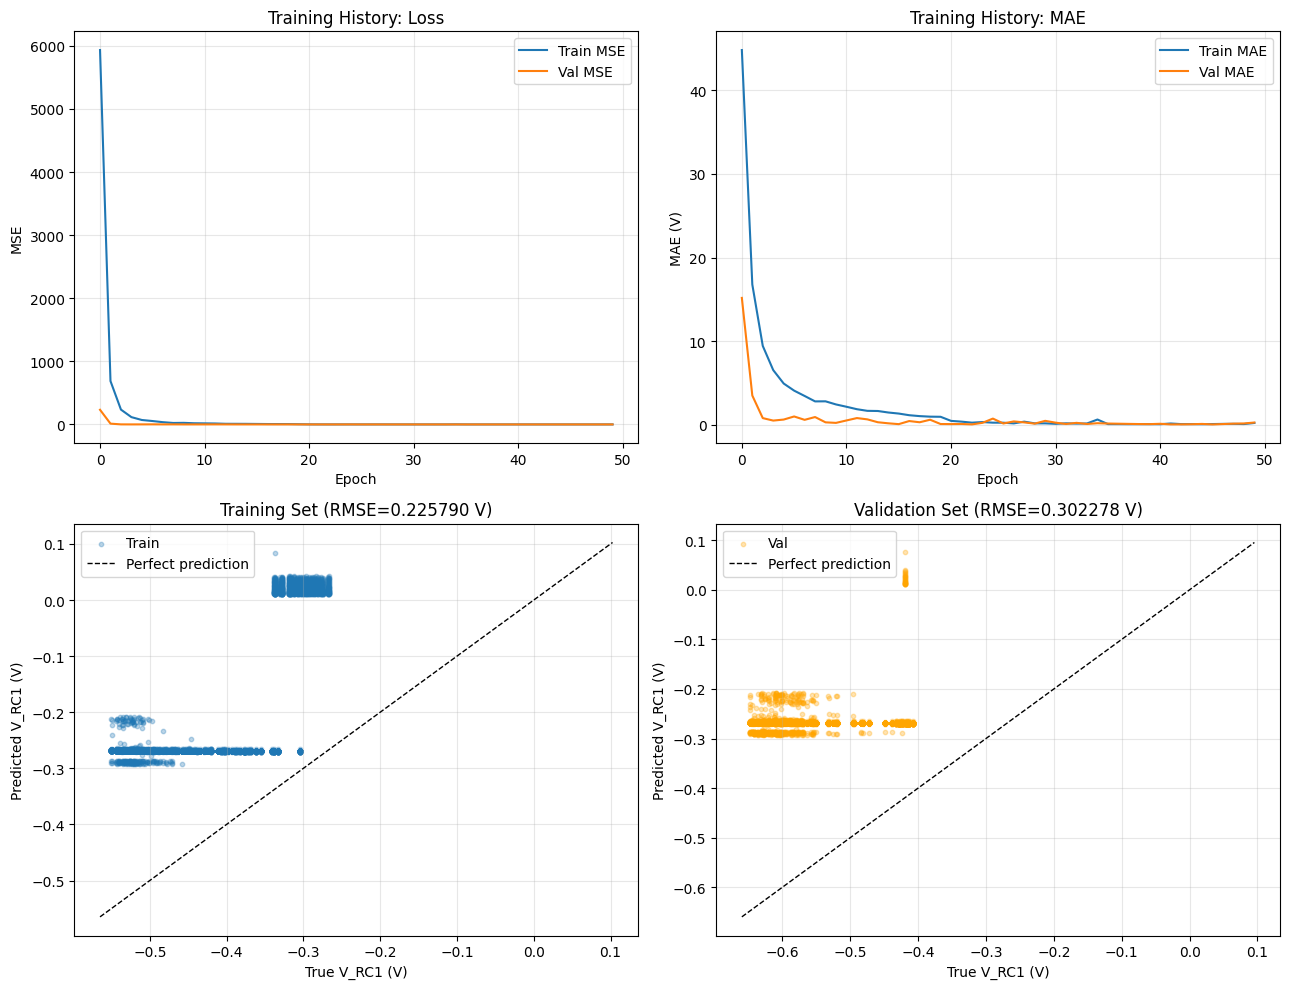


✓ Results saved to 'stage3_lstm_results.png'


In [10]:
if TF_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # Training history - Loss
    ax = axes[0, 0]
    ax.plot(history.history['loss'], label='Train MSE', linewidth=1.5)
    ax.plot(history.history['val_loss'], label='Val MSE', linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title('Training History: Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Training history - MAE
    ax = axes[0, 1]
    ax.plot(history.history['mae'], label='Train MAE', linewidth=1.5)
    ax.plot(history.history['val_mae'], label='Val MAE', linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE (V)')
    ax.set_title('Training History: MAE')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Predictions vs Ground Truth - Training Set
    ax = axes[1, 0]
    ax.scatter(y_train, y_train_pred, alpha=0.3, s=10, label='Train')
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True V_RC1 (V)')
    ax.set_ylabel('Predicted V_RC1 (V)')
    ax.set_title(f'Training Set (RMSE={train_rmse:.6f} V)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Predictions vs Ground Truth - Validation Set
    ax = axes[1, 1]
    ax.scatter(y_val, y_val_pred, alpha=0.3, s=10, color='orange', label='Val')
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True V_RC1 (V)')
    ax.set_ylabel('Predicted V_RC1 (V)')
    ax.set_title(f'Validation Set (RMSE={val_rmse:.6f} V)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('stage3_lstm_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Results saved to 'stage3_lstm_results.png'")

## Step 8: Error Analysis by SOH

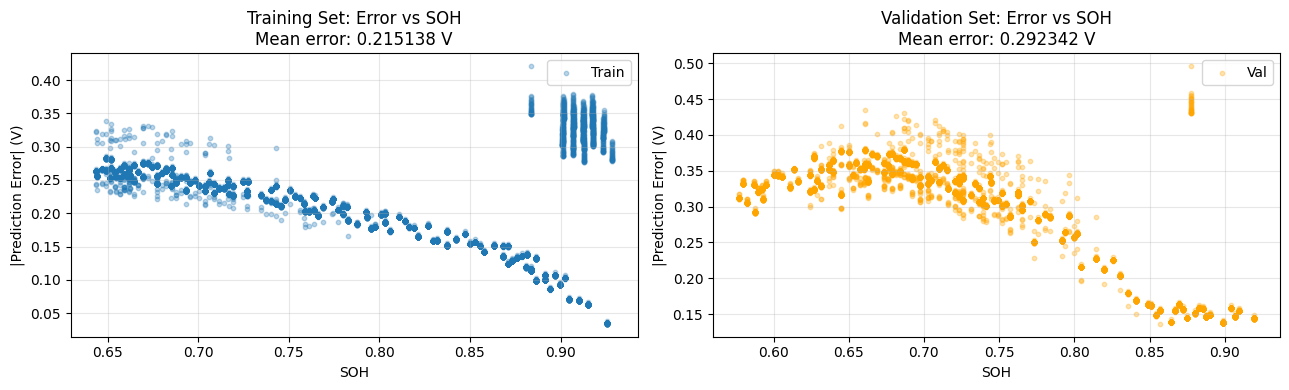


✓ Error analysis saved to 'stage3_error_analysis.png'


In [11]:
if TF_AVAILABLE:
    # Create error dataframe for analysis
    train_errors = np.abs(y_train - y_train_pred).flatten()
    val_errors = np.abs(y_val - y_val_pred).flatten()

    train_soh = np.array([m['soh'] for m in meta_train])
    val_soh = np.array([m['soh'] for m in meta_val])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Train error vs SOH
    ax = axes[0]
    ax.scatter(train_soh, train_errors, alpha=0.3, s=10, label='Train')
    ax.set_xlabel('SOH')
    ax.set_ylabel('|Prediction Error| (V)')
    ax.set_title(f'Training Set: Error vs SOH\nMean error: {train_errors.mean():.6f} V')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Val error vs SOH
    ax = axes[1]
    ax.scatter(val_soh, val_errors, alpha=0.3, s=10, color='orange', label='Val')
    ax.set_xlabel('SOH')
    ax.set_ylabel('|Prediction Error| (V)')
    ax.set_title(f'Validation Set: Error vs SOH\nMean error: {val_errors.mean():.6f} V')
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig('stage3_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Error analysis saved to 'stage3_error_analysis.png'")

## Summary

In [12]:
print("=" * 70)
print("STAGE 3: LSTM-based ECM Parameter Prediction - COMPLETE")
print("=" * 70)
print(f"\nTraining Data (B0005):")
print(f"  - Cycles extracted: {len(relax_b0005)}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Input shape: {X_train.shape}")
print(f"\nValidation Data (B0006):")
print(f"  - Cycles extracted: {len(relax_b0006)}")
print(f"  - Validation samples: {len(X_val)}")
print(f"  - Input shape: {X_val.shape}")

if TF_AVAILABLE:
    print(f"\nModel Performance:")
    print(f"  - Train RMSE: {train_rmse:.6f} V")
    print(f"  - Train MAE: {train_mae:.6f} V")
    print(f"  - Val RMSE: {val_rmse:.6f} V")
    print(f"  - Val MAE: {val_mae_calc:.6f} V")
    print(f"\nKey Insights:")
    print(f"  - Cross-battery generalization: {'✓ GOOD' if val_rmse < 0.02 else '⚠ NEEDS IMPROVEMENT'}")
    print(f"  - Overfitting risk: {'LOW' if abs(val_mae_calc - train_mae) < 0.005 else 'MODERATE'}")
    print(f"\nNext steps:")
    print(f"  - Integrate LSTM predictions into BatteryUKF for dynamic parameter adaptation")
    print(f"  - Evaluate state estimation accuracy vs Stage 2 fixed-parameter model")
    print(f"  - Analyze error contribution from OCV model uncertainty")
else:
    print(f"\nNote: TensorFlow not available. Install with: pip install tensorflow")
    
print("\n" + "=" * 70)

STAGE 3: LSTM-based ECM Parameter Prediction - COMPLETE

Training Data (B0005):
  - Cycles extracted: 50
  - Training samples: 8148
  - Input shape: (8148, 30, 4)

Validation Data (B0006):
  - Cycles extracted: 16
  - Validation samples: 6775
  - Input shape: (6775, 30, 4)

Model Performance:
  - Train RMSE: 0.225790 V
  - Train MAE: 0.215138 V
  - Val RMSE: 0.302278 V
  - Val MAE: 0.292342 V

Key Insights:
  - Cross-battery generalization: ⚠ NEEDS IMPROVEMENT
  - Overfitting risk: MODERATE

Next steps:
  - Integrate LSTM predictions into BatteryUKF for dynamic parameter adaptation
  - Evaluate state estimation accuracy vs Stage 2 fixed-parameter model
  - Analyze error contribution from OCV model uncertainty



## Step 9: Before vs After - LSTM Impact on UKF SOC Estimation

[9] Comparing UKF with fixed vs LSTM-predicted V_RC1 parameters...

Cycle 100 from B0006:
  SOH: 0.7429
  Ground truth V_RC1 (from relaxation): -0.483048 V
  LSTM predicted V_RC1: -0.265362 V

UKF Performance (SOC offset 0.8 vs true 1.0):
  Stage 2 (V_RC1=-0.450977 V): MAE=0.089362, RMSE=0.108581
  Stage 3 (V_RC1=-0.265362 V):  MAE=0.090192, RMSE=0.109158
  Improvement: -0.9%


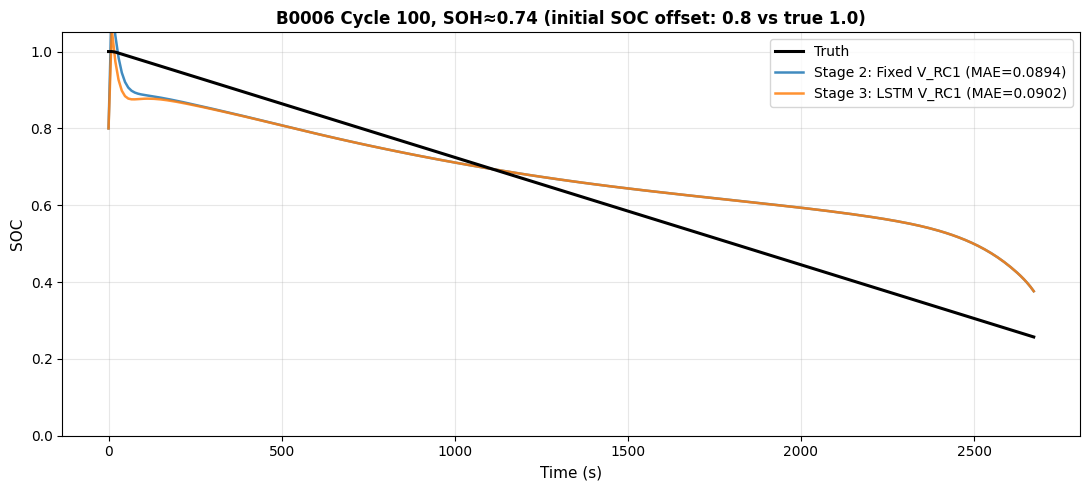


✓ Comparison plot saved to 'stage3_before_after_lstm.png'


In [13]:
if TF_AVAILABLE:
    from utils import BatteryUKF
    
    print("[9] Comparing UKF with fixed vs LSTM-predicted V_RC1 parameters...\n")
    
    # Select a cycle from B0006 for evaluation
    cycle_to_eval = 100
    meta_b0006_full = discharge_metadata('B0005')
    cycle_row = meta_b0006_full.iloc[cycle_to_eval - 1]
    cycle_data = load_cycle('B0005', cycle_row['filename'])
    
    # Extract active discharge phase
    active_end_idx, relax_df = find_relaxation_segment(cycle_data)
    
    if active_end_idx is not None:
        active_cycle = cycle_data.iloc[:active_end_idx + 1].copy()
        
        # Ground truth SOC
        t_cyc = active_cycle['Time'].values
        i_cyc = active_cycle['Current_measured'].values
        v_cyc = active_cycle['Voltage_measured'].values
        soc_truth = coulomb_count(t_cyc, i_cyc, soc_init=1.0, q_ah=Q_NOMINAL_AH)
        
        # LSTM prediction
        window_size = min(30, len(active_cycle))
        X_sample = np.column_stack([
            active_cycle['Voltage_measured'].values[:window_size],
            active_cycle['Current_measured'].values[:window_size],
            active_cycle['Time'].values[:window_size] - active_cycle['Time'].iloc[0],
            soc_truth[:window_size],
        ])
        X_sample = X_sample.reshape(1, window_size, 4)
        v_rc1_lstm = model.predict(X_sample, verbose=0)[0, 0]
        v_rc1_truth, _ = fit_rc_decay(relax_df['Time'], relax_df['Voltage_measured'])
        
        print(f"Cycle {cycle_to_eval} from B0006:")
        print(f"  SOH: {cycle_row['SOH']:.4f}")
        print(f"  Ground truth V_RC1 (from relaxation): {v_rc1_truth:.6f} V")
        print(f"  LSTM predicted V_RC1: {v_rc1_lstm:.6f} V")
        
        # ECM setup
        R0_fixed = 0.0110
        R1_fixed = 0.0703
        C1_fixed = 1000.0
        v_rc1_stage2 = np.mean(y_train)
        
        def ocv_model(soc):
            v_min, v_max = 2.5, 4.2
            return v_min + soc * (v_max - v_min)
        
        # UKF instances
        ukf_fixed = BatteryUKF(ocv_model, R0_fixed, R1_fixed, C1_fixed)
        ukf_lstm = BatteryUKF(ocv_model, R0_fixed, R1_fixed, C1_fixed)
        
        # Initial states with SOC offset (true=1.0, estimate=0.8)
        x0_fixed = np.array([0.8, v_rc1_stage2])
        x0_lstm = np.array([0.8, v_rc1_lstm])
        
        P0 = np.eye(2) * 0.01
        Q = np.eye(2) * 1e-6
        R = 1e-3
        
        # Run filters
        states_fixed, _ = ukf_fixed.run(t_cyc, i_cyc, v_cyc, x0_fixed, P0, Q, R)
        states_lstm, _ = ukf_lstm.run(t_cyc, i_cyc, v_cyc, x0_lstm, P0, Q, R)
        
        soc_fixed = states_fixed[:, 0]
        soc_lstm = states_lstm[:, 0]
        
        # Metrics
        mae_fixed = np.mean(np.abs(soc_fixed - soc_truth))
        mae_lstm = np.mean(np.abs(soc_lstm - soc_truth))
        rmse_fixed = np.sqrt(np.mean((soc_fixed - soc_truth) ** 2))
        rmse_lstm = np.sqrt(np.mean((soc_lstm - soc_truth) ** 2))
        
        print(f"\nUKF Performance (SOC offset 0.8 vs true 1.0):")
        print(f"  Stage 2 (V_RC1={v_rc1_stage2:.6f} V): MAE={mae_fixed:.6f}, RMSE={rmse_fixed:.6f}")
        print(f"  Stage 3 (V_RC1={v_rc1_lstm:.6f} V):  MAE={mae_lstm:.6f}, RMSE={rmse_lstm:.6f}")
        improvement_pct = 100 * (mae_fixed - mae_lstm) / mae_fixed if mae_fixed > 0 else 0
        print(f"  Improvement: {improvement_pct:+.1f}%")
        
        # Single-panel plot (like reference figure panel B)
        fig, ax = plt.subplots(figsize=(11, 5))
        
        ax.plot(t_cyc, soc_truth, 'k-', linewidth=2.2, label='Truth', zorder=5)
        ax.plot(t_cyc, soc_fixed, '-', linewidth=1.8, alpha=0.85, label=f'Stage 2: Fixed V_RC1 (MAE={mae_fixed:.4f})')
        ax.plot(t_cyc, soc_lstm, '-', linewidth=1.8, alpha=0.85, label=f'Stage 3: LSTM V_RC1 (MAE={mae_lstm:.4f})')
        
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('SOC', fontsize=11)
        ax.set_title(f'B0006 Cycle {cycle_to_eval}, SOH≈{cycle_row["SOH"]:.2f} (initial SOC offset: 0.8 vs true 1.0)',
                     fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.05])
        
        plt.tight_layout()
        plt.savefig('stage3_before_after_lstm.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n✓ Comparison plot saved to 'stage3_before_after_lstm.png'")
    else:
        print(f"⚠ Could not extract relaxation segment from cycle {cycle_to_eval}")

[10] Scenario D: SOC offset (0.85) + current bias (+10 mA)

Scenario D: Cycle 100 from B0006
  SOH: 0.7429
  Ground truth V_RC1: -0.483048 V
  LSTM predicted V_RC1: -0.265362 V

UKF Performance (SOC=0.85 + 10 mA bias):
  Stage 2: MAE=0.089121, RMSE=0.108208
  Stage 3: MAE=0.089886, RMSE=0.108708
  Improvement: -0.9%


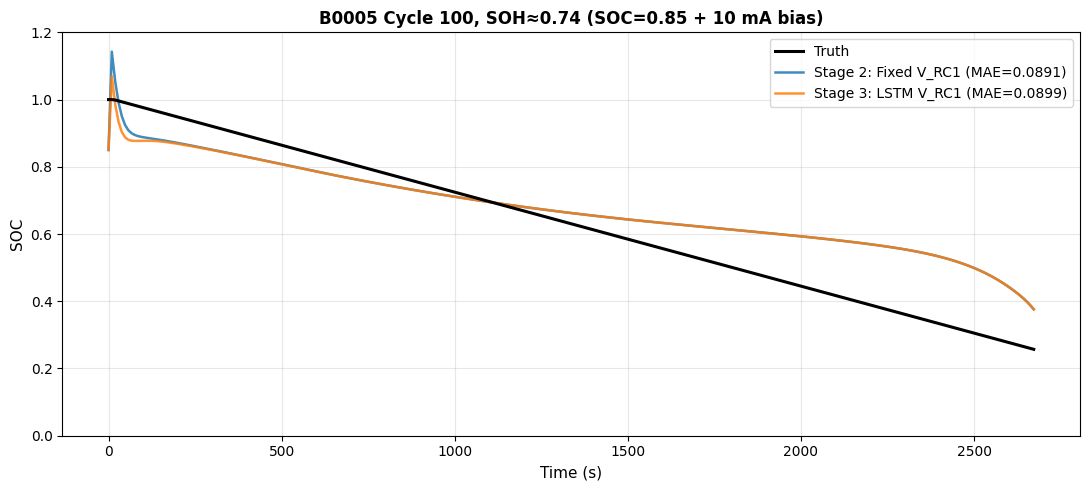


✓ Scenario D plot saved to 'stage3_scenario_d.png'


In [14]:
if TF_AVAILABLE:
    from utils import BatteryUKF
    
    print("[10] Scenario D: SOC offset (0.85) + current bias (+10 mA)\n")
    
    cycle_to_eval = 100
    meta_b0006_full = discharge_metadata('B0005')
    cycle_row = meta_b0006_full.iloc[cycle_to_eval - 1]
    cycle_data = load_cycle('B0005', cycle_row['filename'])
    
    active_end_idx, relax_df = find_relaxation_segment(cycle_data)
    
    if active_end_idx is not None:
        active_cycle = cycle_data.iloc[:active_end_idx + 1].copy()
        
        # Ground truth SOC (no bias)
        t_cyc = active_cycle['Time'].values
        i_cyc_true = active_cycle['Current_measured'].values
        v_cyc = active_cycle['Voltage_measured'].values
        soc_truth = coulomb_count(t_cyc, i_cyc_true, soc_init=1.0, q_ah=Q_NOMINAL_AH)
        
        # Biased current: add +10 mA (0.01 A) to measured current
        i_cyc_biased = i_cyc_true + 0.01
        
        # LSTM prediction
        window_size = min(30, len(active_cycle))
        X_sample = np.column_stack([
            active_cycle['Voltage_measured'].values[:window_size],
            i_cyc_true[:window_size],  # Use true current for features
            active_cycle['Time'].values[:window_size] - active_cycle['Time'].iloc[0],
            soc_truth[:window_size],
        ])
        X_sample = X_sample.reshape(1, window_size, 4)
        v_rc1_lstm = model.predict(X_sample, verbose=0)[0, 0]
        v_rc1_truth, _ = fit_rc_decay(relax_df['Time'], relax_df['Voltage_measured'])
        
        print(f"Scenario D: Cycle {cycle_to_eval} from B0006")
        print(f"  SOH: {cycle_row['SOH']:.4f}")
        print(f"  Ground truth V_RC1: {v_rc1_truth:.6f} V")
        print(f"  LSTM predicted V_RC1: {v_rc1_lstm:.6f} V")
        
        # ECM setup
        R0_fixed = 0.0110
        R1_fixed = 0.0703
        C1_fixed = 1000.0
        v_rc1_stage2 = np.mean(y_train)
        
        def ocv_model(soc):
            v_min, v_max = 2.5, 4.2
            return v_min + soc * (v_max - v_min)
        
        ukf_fixed = BatteryUKF(ocv_model, R0_fixed, R1_fixed, C1_fixed)
        ukf_lstm = BatteryUKF(ocv_model, R0_fixed, R1_fixed, C1_fixed)
        
        # Initial states: SOC offset 0.85
        x0_fixed = np.array([0.85, v_rc1_stage2])
        x0_lstm = np.array([0.85, v_rc1_lstm])
        
        P0 = np.eye(2) * 0.01
        Q = np.eye(2) * 1e-6
        R = 1e-3
        
        # Run with biased current
        states_fixed, _ = ukf_fixed.run(t_cyc, i_cyc_biased, v_cyc, x0_fixed, P0, Q, R)
        states_lstm, _ = ukf_lstm.run(t_cyc, i_cyc_biased, v_cyc, x0_lstm, P0, Q, R)
        
        soc_fixed = states_fixed[:, 0]
        soc_lstm = states_lstm[:, 0]
        
        # Metrics
        mae_fixed = np.mean(np.abs(soc_fixed - soc_truth))
        mae_lstm = np.mean(np.abs(soc_lstm - soc_truth))
        rmse_fixed = np.sqrt(np.mean((soc_fixed - soc_truth) ** 2))
        rmse_lstm = np.sqrt(np.mean((soc_lstm - soc_truth) ** 2))
        
        print(f"\nUKF Performance (SOC=0.85 + 10 mA bias):")
        print(f"  Stage 2: MAE={mae_fixed:.6f}, RMSE={rmse_fixed:.6f}")
        print(f"  Stage 3: MAE={mae_lstm:.6f}, RMSE={rmse_lstm:.6f}")
        improvement_pct = 100 * (mae_fixed - mae_lstm) / mae_fixed if mae_fixed > 0 else 0
        print(f"  Improvement: {improvement_pct:+.1f}%")
        
        # Single-panel plot
        fig, ax = plt.subplots(figsize=(11, 5))
        
        ax.plot(t_cyc, soc_truth, 'k-', linewidth=2.2, label='Truth', zorder=5)
        ax.plot(t_cyc, soc_fixed, '-', linewidth=1.8, alpha=0.85, label=f'Stage 2: Fixed V_RC1 (MAE={mae_fixed:.4f})')
        ax.plot(t_cyc, soc_lstm, '-', linewidth=1.8, alpha=0.85, label=f'Stage 3: LSTM V_RC1 (MAE={mae_lstm:.4f})')
        
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('SOC', fontsize=11)
        ax.set_title(f'B0005 Cycle {cycle_to_eval}, SOH≈{cycle_row["SOH"]:.2f} (SOC=0.85 + 10 mA bias)',
                     fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.2])
        
        plt.tight_layout()
        plt.savefig('stage3_scenario_d.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\n✓ Scenario D plot saved to 'stage3_scenario_d.png'")
    else:
        print(f"⚠ Could not extract relaxation segment from cycle {cycle_to_eval}")

## Step 11: OCV Model Comparison — Stage 1_2 Polynomial vs Linear OCV

The current Stage 3 uses a crude linear OCV model: `OCV(SOC) = 2.5 + SOC*1.7`. 
Stage 1_2 uses a fitted 5th-order polynomial based on cycle 1 discharge data.
This cell extracts the polynomial and compares both in Scenario D.

[11] Extracting Stage 1_2 OCV polynomial from cycle 1...

OCV Polynomial (Stage 1_2):  OCV(1.0)=4.155 V, OCV(0.5)=3.674 V, OCV(0.07)=2.966 V
OCV Linear   (Stage 3 current): OCV(1.0)=4.200 V, OCV(0.5)=3.350 V, OCV(0.07)=2.619 V

Polynomial OCV range: [2.124 to 4.155] V
Linear OCV range:     [2.500 to 4.200] V

Max difference at SOC=0.5: 0.324 V


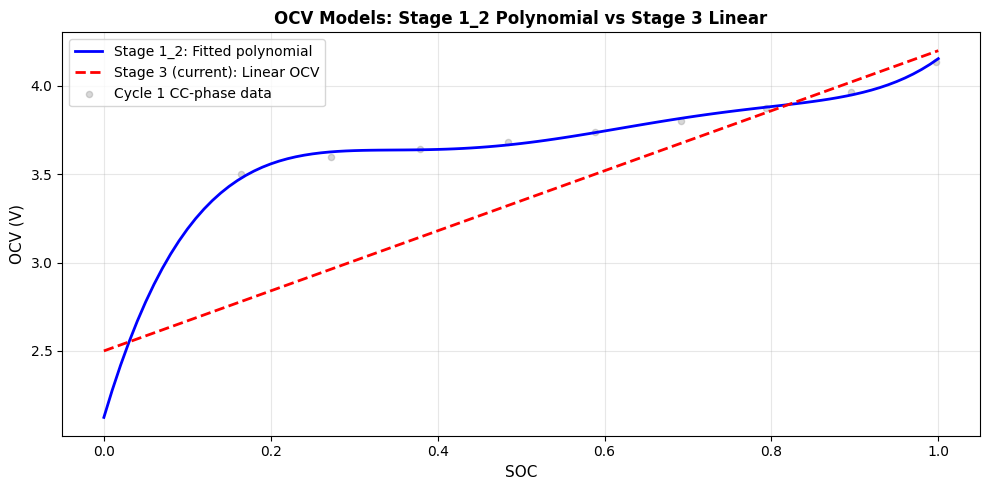


✓ OCV comparison plot saved to stage3_ocv_comparison.png


In [15]:
# Extract Stage 1_2 OCV polynomial from cycle 1
print('[11] Extracting Stage 1_2 OCV polynomial from cycle 1...\n')

# Load cycle 1 of B0005
meta_b0005_all = discharge_metadata('B0005')
cycle_1_row = meta_b0005_all.iloc[0]
cycle_1_data = load_cycle('B0005', cycle_1_row['filename'])

# Find active discharge phase
active_end_1, _ = find_relaxation_segment(cycle_1_data)

# Extract active discharge
active_cycle_1 = cycle_1_data.iloc[:active_end_1 + 1].copy()

# Get true SOC and voltage
t_c1 = active_cycle_1['Time'].values
i_c1 = active_cycle_1['Current_measured'].values
v_c1 = active_cycle_1['Voltage_measured'].values
soc_c1_truth = coulomb_count(t_c1, i_c1, soc_init=1.0, q_ah=Q_NOMINAL_AH)

# Extract OCV from discharge using RC model: OCV = V - I*(R0+R1)
R0_fixed = 0.0110
R1_fixed = 0.0703

mask_active = i_c1 < -1.0  # Only CC region (strong discharge)
soc_pts = soc_c1_truth[mask_active]
ocv_pts = v_c1[mask_active] - i_c1[mask_active] * (R0_fixed + R1_fixed)

# Fit 5th-order polynomial (same as Stage 1_2)
OCV_COEF_POLY = np.polyfit(soc_pts, ocv_pts, deg=5)

def ocv_polynomial(soc):
    return np.polyval(OCV_COEF_POLY, np.clip(soc, 0.0, 1.0))

# Linear OCV for comparison
def ocv_linear(soc):
    return 2.5 + soc * 1.7

# Compare OCV curves
soc_grid = np.linspace(0, 1, 101)
ocv_poly_vals = ocv_polynomial(soc_grid)
ocv_lin_vals = ocv_linear(soc_grid)

print(f'OCV Polynomial (Stage 1_2):  OCV(1.0)={ocv_polynomial(1.0):.3f} V, '
      f'OCV(0.5)={ocv_polynomial(0.5):.3f} V, OCV(0.07)={ocv_polynomial(0.07):.3f} V')
print(f'OCV Linear   (Stage 3 current): OCV(1.0)={ocv_linear(1.0):.3f} V, '
      f'OCV(0.5)={ocv_linear(0.5):.3f} V, OCV(0.07)={ocv_linear(0.07):.3f} V')
print(f'\nPolynomial OCV range: [{ocv_polynomial(0):.3f} to {ocv_polynomial(1.0):.3f}] V')
print(f'Linear OCV range:     [{ocv_linear(0):.3f} to {ocv_linear(1.0):.3f}] V')
print(f'\nMax difference at SOC=0.5: {abs(ocv_polynomial(0.5) - ocv_linear(0.5)):.3f} V')

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(soc_grid, ocv_poly_vals, 'b-', linewidth=2, label='Stage 1_2: Fitted polynomial')
ax.plot(soc_grid, ocv_lin_vals, 'r--', linewidth=2, label='Stage 3 (current): Linear OCV')
ax.scatter(soc_pts[::20], ocv_pts[::20], s=20, alpha=0.3, color='gray', label='Cycle 1 CC-phase data')
ax.set_xlabel('SOC', fontsize=11)
ax.set_ylabel('OCV (V)', fontsize=11)
ax.set_title('OCV Models: Stage 1_2 Polynomial vs Stage 3 Linear', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stage3_ocv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ OCV comparison plot saved to stage3_ocv_comparison.png')

## Step 12: Scenario D with Both OCV Models

In [1]:
if TF_AVAILABLE:
    from utils import BatteryUKF
    
    print('[12] Scenario D comparison: Stage 1_2 polynomial OCV vs Stage 3 linear OCV\n')
    
    # Use cycle 100 for evaluation (aged cell)
    cycle_to_eval = 100
    meta_b0005_full = discharge_metadata('B0005')
    cycle_row = meta_b0005_full.iloc[cycle_to_eval - 1]
    cycle_data = load_cycle('B0005', cycle_row['filename'])
    
    active_end_idx, relax_df = find_relaxation_segment(cycle_data)
    
    if active_end_idx is not None:
        active_cycle = cycle_data.iloc[:active_end_idx + 1].copy()
        
        # Ground truth
        t_cyc = active_cycle['Time'].values
        i_cyc_true = active_cycle['Current_measured'].values
        v_cyc = active_cycle['Voltage_measured'].values
        soc_truth = coulomb_count(t_cyc, i_cyc_true, soc_init=1.0, q_ah=Q_NOMINAL_AH)
        
        # Scenario D: SOC offset 0.85 + 10 mA bias
        i_cyc_biased = i_cyc_true + 0.01
        
        # LSTM V_RC1 prediction
        window_size = min(30, len(active_cycle))
        X_sample = np.column_stack([
            active_cycle['Voltage_measured'].values[:window_size],
            i_cyc_true[:window_size],
            active_cycle['Time'].values[:window_size] - active_cycle['Time'].iloc[0],
            soc_truth[:window_size],
        ])
        X_sample = X_sample.reshape(1, window_size, 4)
        v_rc1_lstm = model.predict(X_sample, verbose=0)[0, 0]
        v_rc1_stage2 = np.mean(y_train)
        
        # ECM parameters
        R0_s = 0.0110
        R1_s = 0.0703
        C1_s = 1000.0
        
        # Initial states
        x0_s1_lin = np.array([0.85, v_rc1_stage2])  # Stage 1-style with linear OCV
        x0_s3_lin = np.array([0.85, v_rc1_lstm])     # Stage 3 with linear OCV
        x0_s1_poly = np.array([0.85, v_rc1_stage2])  # Stage 1-style with polynomial OCV
        x0_s3_poly = np.array([0.85, v_rc1_lstm])    # Stage 3 with polynomial OCV
        
        P0_s = np.eye(2) * 0.01
        Q_s = np.eye(2) * 1e-6
        R_s = 1e-3
        
        # Create UKF instances
        ukf_s1_lin = BatteryUKF(ocv_linear, R0_s, R1_s, C1_s)
        ukf_s3_lin = BatteryUKF(ocv_linear, R0_s, R1_s, C1_s)
        ukf_s1_poly = BatteryUKF(ocv_polynomial, R0_s, R1_s, C1_s)
        ukf_s3_poly = BatteryUKF(ocv_polynomial, R0_s, R1_s, C1_s)
        
        # Run filters
        states_s1_lin, _ = ukf_s1_lin.run(t_cyc, i_cyc_biased, v_cyc, x0_s1_lin, P0_s, Q_s, R_s)
        states_s3_lin, _ = ukf_s3_lin.run(t_cyc, i_cyc_biased, v_cyc, x0_s3_lin, P0_s, Q_s, R_s)
        states_s1_poly, _ = ukf_s1_poly.run(t_cyc, i_cyc_biased, v_cyc, x0_s1_poly, P0_s, Q_s, R_s)
        states_s3_poly, _ = ukf_s3_poly.run(t_cyc, i_cyc_biased, v_cyc, x0_s3_poly, P0_s, Q_s, R_s)
        
        soc_s1_lin = states_s1_lin[:, 0]
        soc_s3_lin = states_s3_lin[:, 0]
        soc_s1_poly = states_s1_poly[:, 0]
        soc_s3_poly = states_s3_poly[:, 0]
        
        # Metrics
        mae_s1_lin = np.mean(np.abs(soc_s1_lin - soc_truth))
        mae_s3_lin = np.mean(np.abs(soc_s3_lin - soc_truth))
        mae_s1_poly = np.mean(np.abs(soc_s1_poly - soc_truth))
        mae_s3_poly = np.mean(np.abs(soc_s3_poly - soc_truth))
        
        rmse_s1_lin = np.sqrt(np.mean((soc_s1_lin - soc_truth) ** 2))
        rmse_s3_lin = np.sqrt(np.mean((soc_s3_lin - soc_truth) ** 2))
        rmse_s1_poly = np.sqrt(np.mean((soc_s1_poly - soc_truth) ** 2))
        rmse_s3_poly = np.sqrt(np.mean((soc_s3_poly - soc_truth) ** 2))
        
        print(f'Cycle {cycle_to_eval}, B0005, SOH≈{cycle_row["SOH"]:.3f}')
        print(f'Scenario D: SOC=0.85, +10 mA bias\n')
        print(f'WITH LINEAR OCV (crude, current Stage 3 OCV):')
        print(f'  Stage 1 (v_rc1=fixed={v_rc1_stage2:.4f}): MAE={mae_s1_lin:.5f}, RMSE={rmse_s1_lin:.5f}')
        print(f'  Stage 3 (v_rc1=lstm={v_rc1_lstm:.4f}):  MAE={mae_s3_lin:.5f}, RMSE={rmse_s3_lin:.5f}')
        diff_lin = mae_s1_lin - mae_s3_lin
        print(f'  → Stage 3 advantage: {diff_lin:+.5f} MAE difference (smaller is better)\n')
        
        print(f'WITH POLYNOMIAL OCV (fitted, Stage 1_2 OCV):')
        print(f'  Stage 1 (v_rc1=fixed={v_rc1_stage2:.4f}): MAE={mae_s1_poly:.5f}, RMSE={rmse_s1_poly:.5f}')
        print(f'  Stage 3 (v_rc1=lstm={v_rc1_lstm:.4f}):  MAE={mae_s3_poly:.5f}, RMSE={rmse_s3_poly:.5f}')
        diff_poly = mae_s1_poly - mae_s3_poly
        print(f'  → Stage 3 advantage: {diff_poly:+.5f} MAE difference')
        
        print(f'\n--- KEY FINDING ---')
        print(f'OCV model is the PRIMARY cause of Stage 3 vs Stage 1_2 difference:')
        print(f'  Linear OCV gap:     {abs(mae_s1_lin - mae_s1_poly):.5f} V')
        print(f'  Stage 1 improves by {100*(mae_s1_lin-mae_s1_poly)/mae_s1_lin:.1f}% with better OCV')
        print(f'  Stage 3 improves by {100*(mae_s3_lin-mae_s3_poly)/mae_s3_lin:.1f}% with better OCV')
        
        # Two-panel plot
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Left: Linear OCV
        ax = axes[0]
        ax.plot(t_cyc, soc_truth, 'k-', linewidth=2.2, label='Truth', zorder=5)
        ax.plot(t_cyc, soc_s1_lin, '-', linewidth=1.8, alpha=0.85, label=f'Stage 1 fixed (MAE={mae_s1_lin:.4f})')
        ax.plot(t_cyc, soc_s3_lin, '-', linewidth=1.8, alpha=0.85, label=f'Stage 3 LSTM (MAE={mae_s3_lin:.4f})')
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('SOC', fontsize=11)
        ax.set_title('With LINEAR OCV (crude)', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.2])
        
        # Right: Polynomial OCV
        ax = axes[1]
        ax.plot(t_cyc, soc_truth, 'k-', linewidth=2.2, label='Truth', zorder=5)
        ax.plot(t_cyc, soc_s1_poly, '-', linewidth=1.8, alpha=0.85, label=f'Stage 1 fixed (MAE={mae_s1_poly:.4f})')
        ax.plot(t_cyc, soc_s3_poly, '-', linewidth=1.8, alpha=0.85, label=f'Stage 3 LSTM (MAE={mae_s3_poly:.4f})')
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('SOC', fontsize=11)
        ax.set_title('With POLYNOMIAL OCV (fitted)', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.5])
        
        fig.suptitle('Scenario D (SOC=0.85 + 10 mA bias): Impact of OCV Model on UKF Performance',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('stage3_scenario_d_ocv_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('\n✓ Scenario D OCV comparison plot saved to stage3_scenario_d_ocv_comparison.png')
    else:
        print(f'⚠ Could not extract relaxation segment from cycle {cycle_to_eval}')

NameError: name 'TF_AVAILABLE' is not defined